In [1]:

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Deixar gráficos mais “limpos”
plt.style.use("default")

PROJECT_ROOT = Path("..").resolve()
DB_EXPORTS = PROJECT_ROOT / "analysis" / "exports"

events_path = DB_EXPORTS / "events_flat.csv"
sessions_path = DB_EXPORTS / "session_metrics.csv"

df_events = pd.read_csv(events_path)
df_sessions = pd.read_csv(sessions_path)

df_events.head(), df_sessions.head()


(   id             ts     created_at  event_id  \
 0   1  1761778511774  1761778511774       NaN   
 1   2  1761778511774  1761778511774       NaN   
 2   3  1761778511774  1761778511774       NaN   
 3   4  1761778512012  1761778512012       NaN   
 4   5  1761778512044  1761778512044       NaN   
 
                           timestamp     totem_id       session_id  \
 0  2025-10-29 22:55:11.473909+00:00  FM-LOCAL-01  sess-jo6nbzl7vr   
 1  2025-10-29 22:55:11.452268+00:00  FM-LOCAL-01  sess-p62ir9h7il   
 2  2025-10-29 22:55:11.473550+00:00  FM-LOCAL-01  sess-wp0y7y17o7   
 3  2025-10-29 22:55:12.010717+00:00  FM-LOCAL-01  sess-jo6nbzl7vr   
 4  2025-10-29 22:55:12.043368+00:00  FM-LOCAL-01  sess-p62ir9h7il   
 
             event_type   channel context__locale       context__modes_enabled  \
 0      consent_updated  no_touch           pt-BR        ["libras", "font_xl"]   
 1      consent_updated     voice           pt-BR  ["high_contrast", "libras"]   
 2      consent_updated     vo

In [2]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DB_EXPORTS = PROJECT_ROOT / "analysis" / "exports"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DB_EXPORTS:", DB_EXPORTS)

events_path = DB_EXPORTS / "events_flat.csv"
sessions_path = DB_EXPORTS / "session_metrics.csv"

print("events_flat existe?", events_path.is_file())
print("session_metrics existe?", sessions_path.is_file())


PROJECT_ROOT: C:\Users\giova\AppData\Local\Programs\Projetos\Sense-Care-Challenge
DB_EXPORTS: C:\Users\giova\AppData\Local\Programs\Projetos\Sense-Care-Challenge\analysis\exports
events_flat existe? True
session_metrics existe? True


In [3]:

# Datas
df_events["timestamp"] = pd.to_datetime(df_events["timestamp"], errors="coerce")
df_sessions["session_start"] = pd.to_datetime(df_sessions["session_start"], errors="coerce")
df_sessions["session_end"] = pd.to_datetime(df_sessions["session_end"], errors="coerce")

# Campos numéricos
for col in ["payload__dwell_ms", "payload__csat"]:
    if col in df_events.columns:
        df_events[col] = pd.to_numeric(df_events[col], errors="coerce")

for col in ["dwell_ms", "csat_mean"]:
    if col in df_sessions.columns:
        df_sessions[col] = pd.to_numeric(df_sessions[col], errors="coerce")

# Converter modes_enabled de JSON string para lista (quando existir)
def parse_modes(x):
    if isinstance(x, str):
        try:
            v = json.loads(x)
            if isinstance(v, list):
                return v
        except Exception:
            pass
    return []

df_sessions["modes_enabled_list"] = df_sessions["modes_enabled"].apply(parse_modes)
df_events["modes_enabled_list"] = df_events.get("context__modes_enabled", "").apply(parse_modes)

len(df_events), len(df_sessions)


(169, 30)

In [4]:

total_events = len(df_events)
total_sessions = len(df_sessions)

csat_global = df_sessions["csat_mean"].mean()
dwell_global = df_sessions["dwell_ms"].mean()

# % sessões com algum modo de acessibilidade
sessions_with_access = df_sessions["modes_enabled_list"].apply(lambda lst: len(lst) > 0).mean() * 100

{
    "total_events": int(total_events),
    "total_sessions": int(total_sessions),
    "csat_medio": round(csat_global, 2),
    "dwell_medio_ms": int(dwell_global),
    "pct_sessoes_com_acessibilidade": round(sessions_with_access, 1),
}


{'total_events': 169,
 'total_sessions': 30,
 'csat_medio': np.float64(4.0),
 'dwell_medio_ms': 20055,
 'pct_sessoes_com_acessibilidade': np.float64(73.3)}

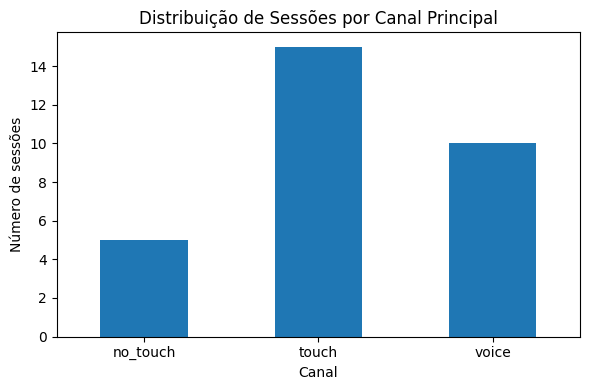

In [5]:

channel_counts = df_sessions["channel_main"].value_counts().sort_index()

plt.figure(figsize=(6,4))
channel_counts.plot(kind="bar")
plt.title("Distribuição de Sessões por Canal Principal")
plt.xlabel("Canal")
plt.ylabel("Número de sessões")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


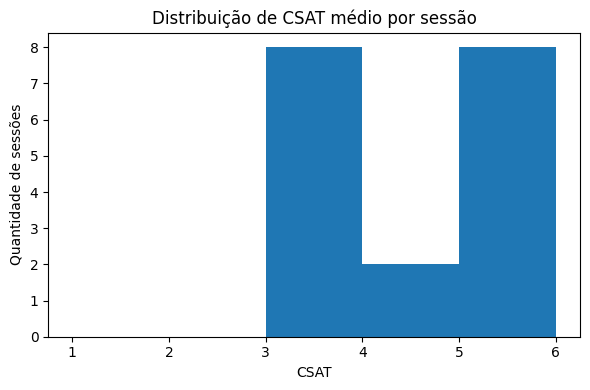

channel_main
no_touch    4.33
touch       3.89
voice       4.00
Name: csat_mean, dtype: float64

In [6]:

plt.figure(figsize=(6,4))
df_sessions["csat_mean"].dropna().plot(kind="hist", bins=[1,2,3,4,5,6])
plt.title("Distribuição de CSAT médio por sessão")
plt.xlabel("CSAT")
plt.ylabel("Quantidade de sessões")
plt.tight_layout()
plt.show()

csat_by_channel = df_sessions.groupby("channel_main")["csat_mean"].mean().round(2)
csat_by_channel


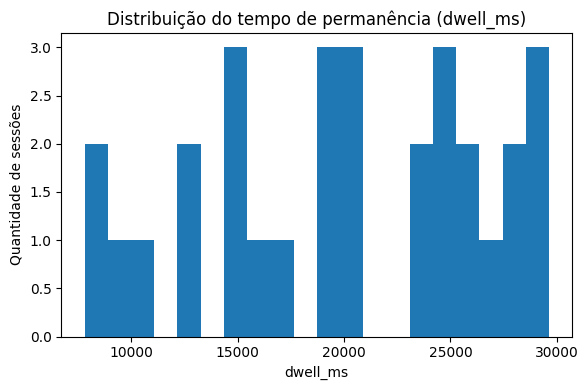

count    30.000000
mean     20.055067
std       6.718695
min       7.800000
25%      15.231500
50%      20.041500
75%      25.492250
max      29.634000
Name: dwell_s, dtype: float64

In [7]:

plt.figure(figsize=(6,4))
df_sessions["dwell_ms"].dropna().plot(kind="hist", bins=20)
plt.title("Distribuição do tempo de permanência (dwell_ms)")
plt.xlabel("dwell_ms")
plt.ylabel("Quantidade de sessões")
plt.tight_layout()
plt.show()

dwell_by_channel = df_sessions.groupby("channel_main")["dwell_ms"].mean().round(0)
dwell_by_channel

df_sessions["dwell_s"] = df_sessions["dwell_ms"] / 1000
df_sessions["dwell_s"].describe()


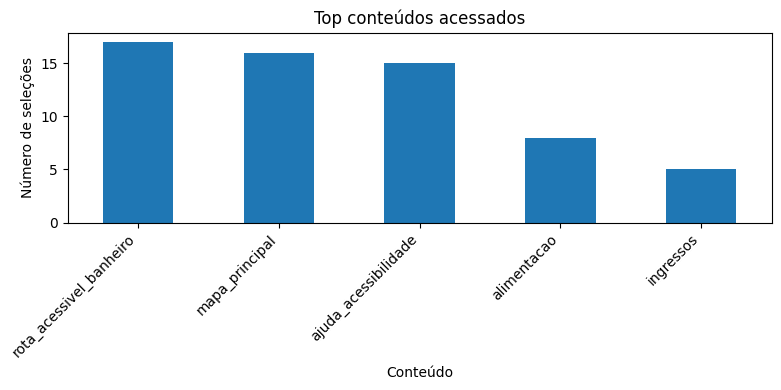

payload__content_id
rota_acessivel_banheiro    17
mapa_principal             16
ajuda_acessibilidade       15
alimentacao                 8
ingressos                   5
Name: count, dtype: int64

In [8]:

mask_content = df_events["event_type"] == "content_selected"
df_contents = df_events[mask_content]

top_contents = (
    df_contents["payload__content_id"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(8,4))
top_contents.plot(kind="bar")
plt.title("Top conteúdos acessados")
plt.xlabel("Conteúdo")
plt.ylabel("Número de seleções")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_contents


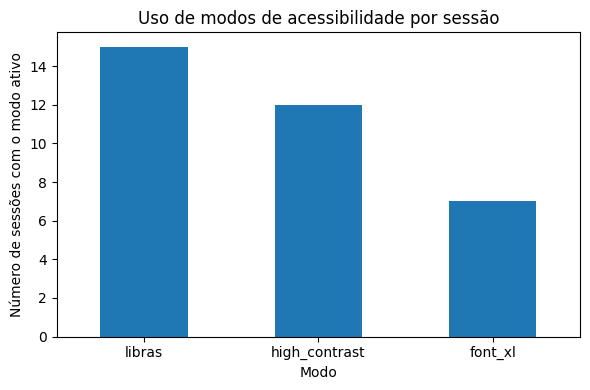

mode
libras           15
high_contrast    12
font_xl           7
Name: count, dtype: int64

In [9]:

rows = []
for _, row in df_sessions.iterrows():
    sess = row["session_id"]
    for mode in row["modes_enabled_list"]:
        rows.append({"session_id": sess, "mode": mode})

df_modes = pd.DataFrame(rows)

mode_counts = df_modes["mode"].value_counts()

plt.figure(figsize=(6,4))
mode_counts.plot(kind="bar")
plt.title("Uso de modos de acessibilidade por sessão")
plt.xlabel("Modo")
plt.ylabel("Número de sessões com o modo ativo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mode_counts


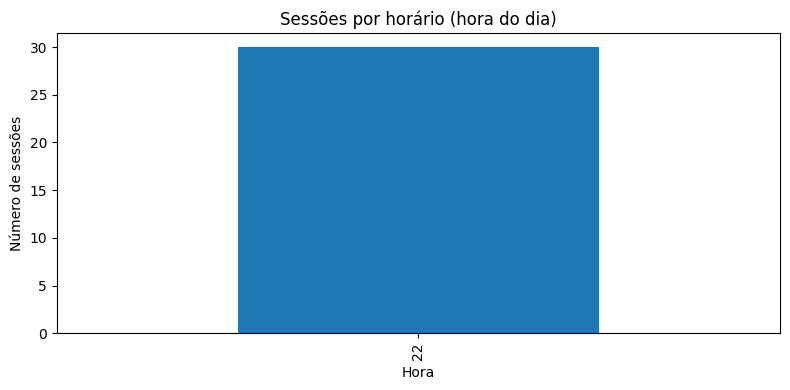

session_hour
22    30
Name: count, dtype: int64

In [10]:

df_sessions["session_hour"] = df_sessions["session_start"].dt.hour

sessions_by_hour = df_sessions["session_hour"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sessions_by_hour.plot(kind="bar")
plt.title("Sessões por horário (hora do dia)")
plt.xlabel("Hora")
plt.ylabel("Número de sessões")
plt.tight_layout()
plt.show()

sessions_by_hour


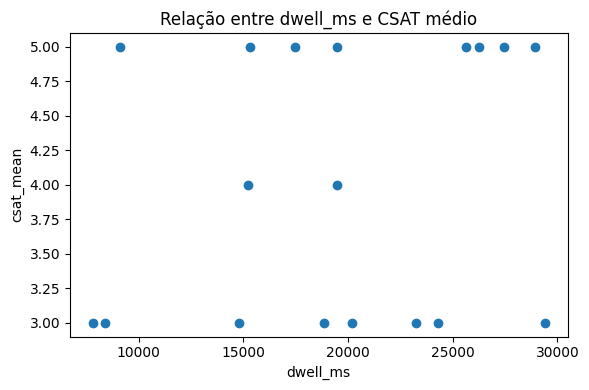

,dwell_ms,csat_mean
dwell_ms,1.000000,0.200079
csat_mean,0.200079,1.000000


In [11]:
plt.figure(figsize=(6,4))
plt.scatter(df_sessions["dwell_ms"], df_sessions["csat_mean"])
plt.title("Relação entre dwell_ms e CSAT médio")
plt.xlabel("dwell_ms")
plt.ylabel("csat_mean")
plt.tight_layout()
plt.show()

df_sessions[["dwell_ms", "csat_mean"]].corr()
